
# 실습: Adaptive Algorithms 2 (탐색 방향 중심)

**계산 실험 주제(목표)**

1. GD와 Momentum의 trajectory 차이를 확인한다.
2. Adam을 **Momentum + RMSProp**의 결합으로 이해한다.
3. Rosenbrock 함수에서 RMSProp과 Adam을 비교한다.

(참고) Nesterov 가속경사의 look-ahead idea를 구현한다.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)



## 1. 목적함수와 기본 plotting 함수

Ill-conditioned quadratic:

$$
f(x,y)=\frac12(x^2+100y^2), \qquad \nabla f(x,y)=(x,100y)^T.
$$


In [ ]:

def quad_f(z):
    x, y = z
    return 0.5*(??)

def quad_g(z):
    x, y = z
    return np.array([??, ??], dtype=float)

def rosen_f(z):
    x, y = z
    return ??

def rosen_g(z):
    x, y = z
    return np.array([-400*x*(y-x*x)-2*(1-x), 200*(y-x*x)], dtype=float)

def plot_quad_contour(paths=None, title=""):
    x = np.linspace(-4.5, 4.5, 250)
    y = np.linspace(-1.2, 1.2, 250)
    X, Y = np.meshgrid(x, y)
    Z = 0.5*(X**2 + 100*Y**2)
    plt.figure(figsize=(8,5))
    plt.contour(X, Y, Z, levels=np.geomspace(0.05,80,18))
    plt.scatter([0], [0], marker="*", s=180, label="minimizer")
    if paths:
        for name, p in paths.items():
            p = np.array(p)
            plt.plot(p[:,0], p[:,1], marker="o", markersize=2, linewidth=1.4, label=name)
            plt.scatter([p[0,0]], [p[0,1]], marker="D", s=50)
    plt.grid(True, alpha=0.3)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_rosenbrock_contour(paths=None, title=""):
    x = np.linspace(-2,2,400)
    y = np.linspace(-1,3,400)
    X, Y = np.meshgrid(x,y)
    Z = 100*(Y-X**2)**2 + (1-X)**2
    plt.figure(figsize=(8,6))
    plt.contour(X, Y, Z, levels=np.geomspace(0.1,1000,25))
    plt.scatter([1], [1], marker="*", s=180, label="minimizer")
    if paths:
        for name, p in paths.items():
            p = np.array(p)
            plt.plot(p[:,0], p[:,1], linewidth=1.4, label=name)
            plt.scatter([p[0,0]], [p[0,1]], marker="D", s=50)
    plt.grid(True, alpha=0.3)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.show()



## 2. GD와 Momentum 구현

GD:

$$
\theta_{k+1}=\theta_k-\eta \nabla f(\theta_k).
$$

Momentum:

$$
v_{k+1}=\beta v_k-\eta g_k,
\qquad
\theta_{k+1}=\theta_k+v_{k+1}.
$$


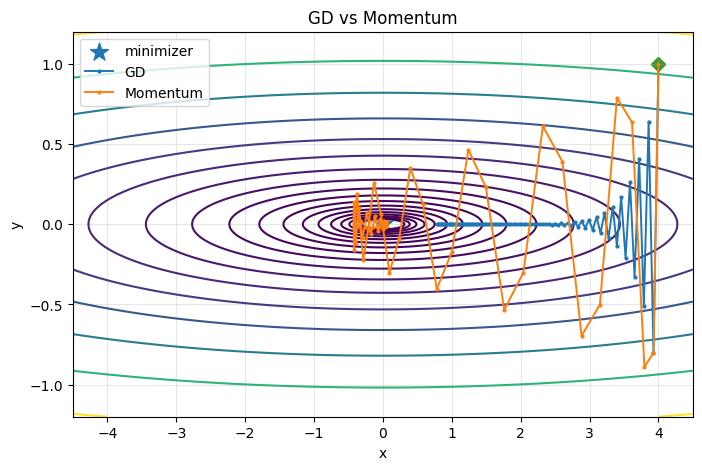

In [ ]:

def algo_gd(grad, x0, lr=0.01, steps=100):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    losses = []
    for k in range(steps):
        losses.append(None)
        x = x - lr*grad(x)
        path.append(x.copy())
    return np.array(path)

def algo_momentum(grad, x0, lr=0.01, beta=0.9, steps=100):
    x = np.array(x0, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    for k in range(steps):
        g = grad(x)
        v = beta*v - lr*g
        x = x + v
        path.append(x.copy())
    return np.array(path)

x0 = np.array([4.0, 1.0])
path_gd = algo_gd(quad_g, x0, lr=0.018, steps=90)
path_mom = algo_momentum(quad_g, x0, lr=0.018, beta=0.85, steps=90)   # beta tunning 필요
plot_quad_contour({"GD": path_gd, "Momentum": path_mom}, "GD vs Momentum")



### **계산 실험(실습) 1**

다음 값을 바꾸어 trajectory가 어떻게 변하는지 확인하세요.

- `lr = 0.005, 0.01, 0.018`
- `beta = 0.5, 0.8, 0.95`



## (참고) Nesterov 가속 경사 구현

Nesterov는 look-ahead 위치에서 gradient를 계산한다.

$$
\tilde\theta_k=\theta_k+\beta v_k,
\qquad
v_{k+1}=\beta v_k-\eta \nabla f(\tilde\theta_k),
\qquad
\theta_{k+1}=\theta_k+v_{k+1}
$$


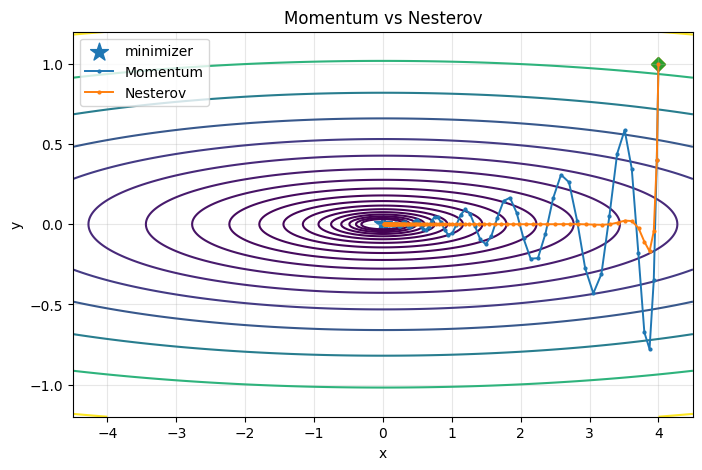

In [ ]:

def algo_nesterov(grad, x0, lr=0.01, beta=0.9, steps=100):
    x = np.array(x0, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    for k in range(steps):
        lookahead = x + beta*v
        g = grad(lookahead)
        v = beta*v - lr*g
        x = x + v
        path.append(x.copy())
    return np.array(path)

path_mom2 = algo_momentum(quad_g, x0, lr=0.006, beta=0.85, steps=100)
path_nag = algo_nesterov(quad_g, x0, lr=0.006, beta=0.85, steps=100)
plot_quad_contour({"Momentum": path_mom2, "Nesterov": path_nag}, "Momentum vs Nesterov")



## 3. RMSProp과 Adam 구현

RMSProp:

$$
v_{k+1}=\beta v_{k}+(1-\beta)(g_k\odot g_k),
\qquad
\theta_{k+1}=\theta_k-\eta\frac{g_k}{\sqrt{v_{k+1}}+\epsilon}.
$$

Adam:

$$
m_{k+1}=\beta_1m_{k}+(1-\beta_1)g_k,
$$

$$
v_{k+1}=\beta_2v_{k}+(1-\beta_2)(g_k\odot g_k),
$$

$$
\hat m_{k+1}=\frac{m_{k+1}}{1-\beta_1^k},
\qquad
\hat v_{k+1}=\frac{v_{k+1}}{1-\beta_2^k}.
$$

$$
\theta_{k+1}=\theta_k-\eta\frac{\hat m_{k+1}}{\sqrt{\hat v_{k+1}}+\epsilon}.
$$


In [ ]:

def algo_rmsprop(grad, x0, lr=0.001, beta=0.9, eps=1e-8, steps=500):
    x = np.array(x0, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    losses = []
    for k in range(steps):
        g = grad(x)
        v = beta*v + (1-beta)*(g*g)
        x = x - lr*g/(np.sqrt(v)+eps)
        path.append(x.copy())
    return np.array(path)

def algo_adam(grad, x0, lr=0.03, beta1=0.9, beta2=0.999, eps=1e-8, steps=500):
    x = np.array(x0, dtype=float)
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    path = [x.copy()]
    for k in range(1, steps+1):
        g = grad(x)
        m = beta1*m + (1-beta1)*g
        v = beta2*v + (1-beta2)*(g*g)
        mh = m/(1-beta1**k)
        vh = v/(1-beta2**k)
        x = x - lr*mh/(np.sqrt(vh)+eps)
        path.append(x.copy())
    return np.array(path)



## 4. Adam vs RMSProp 비교: Rosenbrock 함수

$$
f(x,y)=100(y-x^2)^2+(1-x)^2,
\qquad
\arg\min f=(1,1).
$$


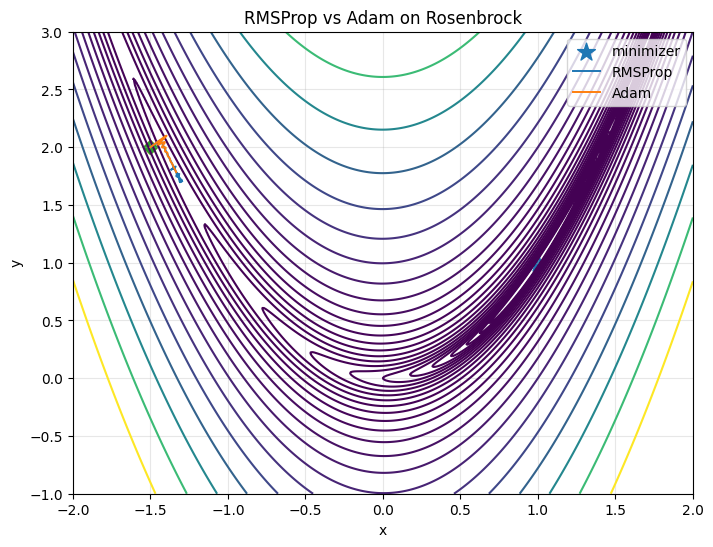

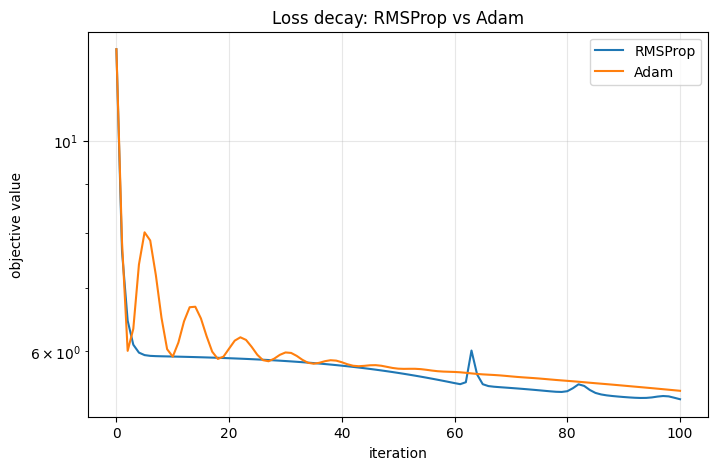

Final RMSProp point: [-1.2958  1.7051] loss= 5.33851313709882
Final Adam point   : [-1.3337  1.7842] loss= 5.449159495454455


In [ ]:

x0_ros = np.array([-1.5, 2.0])
path_rms = algo_rmsprop(rosen_g, x0_ros, lr=0.01, beta=0.9, steps=100)
path_adam = algo_adam(rosen_g, x0_ros, lr=0.03, beta1=0.9, beta2=0.999, steps=100)
plot_rosenbrock_contour({"RMSProp": path_rms, "Adam": path_adam}, "RMSProp vs Adam on Rosenbrock")

loss_rms = np.array([rosen_f(z) for z in path_rms])
loss_adam = np.array([rosen_f(z) for z in path_adam])
plt.figure(figsize=(8,5))
plt.plot(loss_rms, label="RMSProp")
plt.plot(loss_adam, label="Adam")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("objective value")
plt.title("Loss decay: RMSProp vs Adam")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Final RMSProp point:", path_rms[-1], "loss=", loss_rms[-1])
print("Final Adam point   :", path_adam[-1], "loss=", loss_adam[-1])



### **계산 실험(실습) 2**

Adam의 파라미터를 바꾸어 보세요.

- `lr = 0.005, 0.01, 0.03, 0.05`
- `beta1 = 0.5, 0.9, 0.99`
- `beta2 = 0.9, 0.99, 0.999`

질문: 어떤 값에서 가장 안정적으로 수렴하나요?



## 5. Bias correction 확인

간단한 1변수 함수:

$$
f(x)=x^2, \qquad x_0=4.
$$


In [ ]:

x = 4.0
m = 0.0
v = 0.0
lr = 0.1
beta1 = 0.9
beta2 = 0.999
print("k | x | g | m | m_hat | v | sqrt(v_hat) | x_new")
for k in range(1, 4):
    g = 2*x
    m = beta1*m + (1-beta1)*g
    v = beta2*v + (1-beta2)*g*g
    mh = m/(1-beta1**k)
    vh = v/(1-beta2**k)
    x_new = x - lr*mh/(np.sqrt(vh)+1e-8)
    print(k, f"{x:.4f}", f"{g:.4f}", f"{m:.4f}", f"{mh:.4f}", f"{v:.6f}", f"{np.sqrt(vh):.4f}", f"{x_new:.4f}")
    x = x_new


k | x | g | m | m_hat | v | sqrt(v_hat) | x_new
1 4.0000 8.0000 0.8000 8.0000 0.064000 8.0000 3.9000
2 3.9000 7.8000 1.5000 7.8947 0.124776 7.9006 3.8001
3 3.8001 7.6001 2.1100 7.7860 0.182413 7.8016 3.7003
